# Reinforcement Learning Programming Assignment

## MinAtar: Learning to Play Atari-Style Games

This assignment asks you to design, implement, and analyze reinforcement learning algorithms on MinAtar, a set of simplified Atari-style environments. MinAtar provides the visual complexity of Atari games at reduced computational cost: observations are 10×10 pixel grids with a small number of channels, and episodes run faster than their full-scale counterparts.

You will work primarily with **Breakout**, then test whether your methods transfer to other MinAtar games.

### Objectives

By the end of this assignment, you should be able to:

- Analyze an RL environment: state space, action space, reward structure, and episode dynamics
- Select and justify appropriate state representations for learning
- Implement at least two RL algorithms: one classical, one using neural networks
- Interpret learned policies through visualization and quantitative analysis
- Diagnose training issues and apply techniques to address them
- Evaluate generalization across different environments

### Deliverables

Submit a single Jupyter notebook that serves as both your implementation and your report. Your notebook should:

1. **Run end-to-end** without errors
2. **Document your approach** with clear explanations in markdown cells
3. **Present results** with well-labeled figures and tables
4. **Analyze findings** with interpretation of what works, what fails, and why

### Rules

- **Implement RL algorithms yourself.** Do not use RL libraries (stable-baselines, RLlib, CleanRL, etc.)
- **Standard libraries are allowed.** PyTorch, NumPy, scikit-learn, matplotlib, and similar tools are permitted.
- **Cite your sources.** If you adapt an algorithm from a paper or other resource, reference it.

---
## Part 0: Environment and Baselines

The code below sets up the MinAtar Breakout environment and provides two baseline policies for comparison:

- **Random policy**: selects actions uniformly at random
- **Heuristic policy**: moves the paddle toward the ball's horizontal position


In [1]:
!pip install numpy gymnasium minatar torch

In [2]:
import numpy as np
import torch
import gymnasium as gym
from minatar import Environment
from minatar.gym import register_envs
import torch.nn as nn
import torch.nn.functional as F
from collections import deque
import random

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

if "MinAtar/Breakout-v1" not in gym.envs.registry:
    register_envs()

In [3]:
def random_policy(observation, num_actions):
    return np.random.randint(num_actions)

In [4]:
def breakout_heuristic_policy(observation, num_actions):
    paddle_channel = observation[:, :, 0]
    ball_channel = observation[:, :, 1]

    paddle_pos = np.where(paddle_channel == 1)
    ball_pos = np.where(ball_channel == 1)

    if len(paddle_pos[1]) == 0 or len(ball_pos[1]) == 0:
        return 0

    paddle_x = paddle_pos[1].mean()
    ball_x = ball_pos[1].mean()

    if ball_x < paddle_x:
        return 1
    elif ball_x > paddle_x:
        return 2
    else:
        return 0

In [5]:
def run_episode(env, policy_fn):
    observation, info = env.reset()
    num_actions = env.action_space.n

    total_reward = 0
    terminated = False
    truncated = False
    steps = 0

    while not (terminated or truncated):
        action = policy_fn(observation, num_actions)
        observation, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        steps += 1

    return total_reward, steps


def evaluate_policy(env, policy_fn, num_episodes=100):
    rewards = []
    steps_list = []

    for _ in range(num_episodes):
        total_reward, steps = run_episode(env, policy_fn)
        rewards.append(total_reward)
        steps_list.append(steps)

    return np.array(rewards), np.array(steps_list)

In [6]:
env = gym.make("MinAtar/Breakout-v1")
env.reset()

print(f"Observation shape: {env.observation_space.shape}")
print(f"Number of actions: {env.action_space.n}")

Observation shape: (10, 10, 4)
Number of actions: 3


In [7]:
num_episodes = 100

random_rewards, random_steps = evaluate_policy(env, random_policy, num_episodes)
print(f"Random Policy:")
print(f"  Reward: {random_rewards.mean():.2f} +/- {random_rewards.std():.2f}")
print(f"  Steps:  {random_steps.mean():.2f} +/- {random_steps.std():.2f}")

heuristic_rewards, heuristic_steps = evaluate_policy(env, breakout_heuristic_policy, num_episodes)
print(f"\nHeuristic Policy:")
print(f"  Reward: {heuristic_rewards.mean():.2f} +/- {heuristic_rewards.std():.2f}")
print(f"  Steps:  {heuristic_steps.mean():.2f} +/- {heuristic_steps.std():.2f}")

Random Policy:
  Reward: 0.43 +/- 0.67
  Steps:  10.36 +/- 6.88

Heuristic Policy:
  Reward: 8.26 +/- 9.21
  Steps:  96.62 +/- 106.71


In [8]:
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML


def render_frame(env):
    frame = env.render()
    return (frame * 255).astype(np.uint8)


def run_episode_with_frames(env, policy_fn, max_steps=500):
    observation, info = env.reset()
    num_actions = env.action_space.n
    frames = [render_frame(env)]

    total_reward = 0
    terminated = False
    truncated = False
    steps = 0

    while not (terminated or truncated) and steps < max_steps:
        action = policy_fn(observation, num_actions)
        observation, reward, terminated, truncated, info = env.step(action)
        frames.append(render_frame(env))
        total_reward += reward
        steps += 1

    return frames, total_reward, steps


def animate_episode(frames, interval=50):
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.axis("off")
    img = ax.imshow(frames[0], interpolation="nearest")

    def update(frame):
        img.set_array(frame)
        return [img]

    anim = animation.FuncAnimation(
        fig, update, frames=frames, interval=interval, blit=True
    )
    plt.close(fig)
    return anim


env_visual = gym.make("MinAtar/Breakout-v1", render_mode="rgb_array", disable_env_checker=True)
env_visual.reset()

frames, reward, steps = run_episode_with_frames(env_visual, breakout_heuristic_policy)
print(f"Episode: Reward = {reward}, Steps = {steps}")

anim = animate_episode(frames, interval=100)
HTML(anim.to_jshtml())

Episode: Reward = 0, Steps = 6


---

## Part 1: Environment Analysis [5 marks]

Before designing learning algorithms, you must understand the environment.

### Questions to Address

1. **State space**: What is the shape of the observations? What does each channel represent? How many unique states are theoretically possible?

2. **Action space**: What actions are available? How do they affect the game state?

3. **Reward structure**: When and how frequently does the agent receive rewards? What is the typical range of episode returns?

4. **Episode dynamics**: What causes an episode to terminate? What is the distribution of episode lengths under the random and heuristic policies?

5. **Stochasticity**: Is the environment deterministic or stochastic? If stochastic, what are the sources of randomness?

Visualize observations, reward distributions, and episode statistics to support your analysis.

1. The observation is of shape `10x10x4`. The two first channels are the position on the grid (x, y). Then the last channel represents the state representation: each position can be the ball, a brick, the trail of the ball (giving the direction), the paddle. If a position is not in the observation, then it's nothing.

This is an enumeration problem:
- we choose the number of bricks: $n_{br} \in [0, 30]$
- we choose the position of the paddle $n_p =10$ choices
- we choose the position of the ball: $n_{ba}= 10x10 - 1- n_{br} \approx  100$ (-1 because of the paddle
- we choose the position of the trail, we have 4 directions: $n_t=4$
- we choose where are the bricks : they can be wherever they want on 3 raws: $n_{pbr} = {C}_{n_{br}}^{30}$

Finally we have a number of states of
$$n_s = \sum_{k=0}^{30} n_p*n_{ba}*n_t*n_{pbr} = n_p*n_{ba}*n_t *\sum_{k=0}^{30} {C}_{n_{br}}^{30}  = 2^{30} * 10 * 100 * 4 = 4*10^{12} $$

This number is huge, we can't try all of them.





2. We have three possible actions: moving the paddle to the right, left or do nothing. This affect the game because if when the ball doesn't touch the paddle when it comes to the ground, it's game over. Thus it's important to move the paddle so that it's position will match the ball position at the bottom.

3.The agent receive reward when it touches bricks. This happens when the ball is in the upper part of the game. It can happens whenever during the game. The reward when touching a brick can be ⁉
- 1: the normal reward
- 1 + 3: if the brick touched was the last one of the three rows.

Thus the range of return is $r \in [0, +\infty[$

4. An episode terminates when the ball touch the ground.

On average, the length of an episode is:
- random policy: `9.8`.
- heuristic policy: `103.42`

5. The environment is stochastic. The initial condition is something random for the ball position at the top and the trail. We thus have 20 different initial condition. Then during the game, the physics is deterministic.

---

## Part 2: A Classical RL Method [8 marks]

Implement a reinforcement learning algorithm that does not use neural networks for function approximation.

### Requirements

- Choose an appropriate algorithm given your analysis of the state space
- Choose an appropriate state representation
- Justify your choices based on the environment properties you identified in Part 1

### Questions to Address

1. **State representation**: How do you represent the state? Why is this representation appropriate for your chosen algorithm?

2. **Algorithm description**: What algorithm did you implement? Write out the update rules.

3. **Hyperparameters**: What hyperparameters does your method have? How did you select their values?

4. **Learning curves**: Plot the return during training. Include error bars or confidence intervals if you run multiple seeds.

5. **Comparison to baselines**: How does your trained policy compare to the random and heuristic baselines?

1. **State representation**: In order to represent our space, we need to lower the dimension of the problem. A first thing could be to give to our algorithm only the position of the ball, the trail and the position of the paddle. Thanks to that, it will be able to survive and luckily it will be able to touch some bricks and win some points.

2. **Algorithm description**:

We will use a Q learning algorithm. With our new state representation, we have a 10 possible states for the paddle, 100 for the ball and 4 for the direction. Thus we have 4000 possible states. Our Q table will be of dimension `4000x3` because we have 3 possible actions.

We will update at the end of each simulation the Q table like that:

$$Q(s, a) = Q(s, a) + \alpha(r + \gamma \text{max}_{a'}(Q(s', a')) - Q(s,a))$$

With $s'$ the new state.

We will then choose the policy with an $\epsilon$-greedy policy:

$$p \sim U(0,1)$$

if $p > \epsilon$:

$$\pi = argmin(Q(s,a))$$

else:
$$\pi = random$$

The hyperparameters are:

- $\alpha$: to what extend we update our weights
- $\gamma$: to what extend the weights are diffused
- $\epsilon$: to what extend we take random action
- $d \in [0, 1]$: to what extend the exploration change: $\epsilon_{t+1} = \epsilon_t*d$


**How to select the values**:

- $\alpha$: A value of 0.1 was chosen to ensure that the agent learns incrementally.
- $\gamma$: Because Breakout requires long-term survival to achieve high scores, a high gamma ($\gamma=0.99$) is essential. This allows the reward from hitting a brick in the future to propagate back to the current paddle movement, even if that movement happens many steps earlier.
- $\epsilon$: we initiate $\epsilon=0.5$ so that at first it explores a lot.
- $d=0.995$: At the step number 10 000, $\epsilon \approx 0$. Thus at the end we can just learn well our policy.




4. **Learning curves**:

5.**Comparison to baseline**: The algorithm is learning a policy that is able to have some reward. On average, the length of an episode is `120`. Thus it is slightly better than the heuristic policy. But it is still not the perfect policy.

In [9]:
def init_Q():
  """init the Q table"""
  Q = {}
  for x_ball in range(0, 10):
    for y_ball in range(0, 10):
      for paddle_x in range(0, 10):
        for value_trail in range(0, 4):
          state = (x_ball, y_ball, value_trail, paddle_x)
          Q[state] = np.zeros(3)
  return Q

In [10]:
class HyperParam:
  def __init__(self, alpha, gamma, epsilon_init, d, nb_epochs, display_every, punition_terminated):
    self.alpha = alpha
    self.gamma = gamma
    self.epsilon_init = epsilon_init
    self.d = d
    self.nb_epochs = nb_epochs
    self.display_every = display_every
    self.punition_terminated = punition_terminated





In [11]:
def find_state_Q(observation):
  """From an observation give the state for the Q learning"""
  paddle_channel = observation[:, :, 0]
  ball_channel = observation[:, :, 1]
  tail_channel = observation[:, :, 2]

  paddle_pos = np.where(paddle_channel == 1)
  ball_pos = np.where(ball_channel == 1)
  trail_pos = np.where(tail_channel == 1)

  paddle_x = paddle_pos[1].mean()
  ball_x = ball_pos[1].mean()
  ball_y = ball_pos[0].mean()
  trail_x = trail_pos[0].mean()
  trail_y = trail_pos[1].mean()

  # find if the trail is up left, up right, low right, low left of the ball
  if trail_x > ball_x:
    if trail_y > ball_y:
      value_trail = 0
    else:
      value_trail = 1
  else:
    if trail_y > ball_y:
      value_trail = 2
    else:
      value_trail = 3

  return (ball_x, ball_y, value_trail, paddle_x)



In [12]:
def update_Q(Q, state, action, new_state, reward, hyper_param, terminated):
  """Update Q with the Belleman equation"""
  if not terminated:
    best_q_value_new_state = np.max(Q[new_state])
    Q[state][action] += hyper_param.alpha * (reward + hyper_param.gamma * best_q_value_new_state - Q[state][action])
  else:
    Q[state][action] += hyper_param.alpha * (hyper_param.punition_terminated - Q[state][action])
  return Q





In [13]:
def find_Q_policy(Q, epsilon=None, with_exploration=False):
  """Return the policy from the Q learning"""
  def policy(observation, num_actions):
    """The policy it returns"""
    state = find_state_Q(observation)
    if with_exploration:
      if np.random.uniform(0,1) < epsilon:
        return np.random.randint(num_actions)
    return np.argmax(Q[state])
  return policy



In [14]:
def run_episode_Q_learning_training(env, Q, epoch):
  """Run one episode of Q learning"""
  observation, info = env.reset()
  num_actions = env.action_space.n

  total_reward = 0
  terminated = False
  truncated = False
  steps = 0

  while not (terminated or truncated):
      epsilon = hyper_param.epsilon_init * (hyper_param.d**epoch)
      policy = find_Q_policy(Q, epsilon, with_exploration=True)
      action = policy(observation, num_actions)
      state = find_state_Q(observation)
      observation, reward, terminated, truncated, info = env.step(action)
      new_state = find_state_Q(observation)
      Q = update_Q(Q, state, action, new_state, reward, hyper_param, terminated)
      total_reward += reward
      steps += 1

  return total_reward, steps, Q



In [15]:
### Initialisation of the variables:


hyper_param = HyperParam(
    alpha=0.1,
    gamma=0.99,
    epsilon_init=0.5,
    d=0.9995,
    nb_epochs=15000,
    display_every=500,
    punition_terminated=-10
    )

In [27]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
list_steps_s = []
list_reward_s = []
list_Q_s = []



for _ in range(3):
  env.reset(seed=SEED)
  Q_table = init_Q()
  list_steps = []
  list_reward = []
  for epoch in range(hyper_param.nb_epochs):
    total_reward, steps, Q_table = run_episode_Q_learning_training(env, Q_table, epoch)
    list_reward.append(total_reward)
    list_steps.append(steps)
    if epoch % hyper_param.display_every == 0:
      print(f"Epoch: {epoch} - total reward: {np.mean(list_reward[-500:])} - number of steps: {np.mean(list_steps[-500:])}")
  list_steps_s.append(list_steps)
  list_reward_s.append(list_reward)
  list_Q_s.append(Q_table)
  SEED += 1



Epoch: 0 - total reward: 0.0 - number of steps: 6.0
Epoch: 500 - total reward: 1.07 - number of steps: 17.1
Epoch: 1000 - total reward: 1.564 - number of steps: 22.292
Epoch: 1500 - total reward: 2.14 - number of steps: 28.5
Epoch: 2000 - total reward: 2.536 - number of steps: 32.636
Epoch: 2500 - total reward: 2.8 - number of steps: 35.42
Epoch: 3000 - total reward: 3.048 - number of steps: 38.088
Epoch: 3500 - total reward: 3.026 - number of steps: 37.892
Epoch: 4000 - total reward: 3.484 - number of steps: 42.844
Epoch: 4500 - total reward: 3.736 - number of steps: 45.436
Epoch: 5000 - total reward: 4.01 - number of steps: 48.436
Epoch: 5500 - total reward: 4.572 - number of steps: 54.324
Epoch: 6000 - total reward: 4.436 - number of steps: 52.84
Epoch: 6500 - total reward: 4.926 - number of steps: 58.044
Epoch: 7000 - total reward: 5.234 - number of steps: 61.312
Epoch: 7500 - total reward: 5.932 - number of steps: 68.948
Epoch: 8000 - total reward: 6.604 - number of steps: 76.308


In [28]:
# Préparation des données à sauvegarder
checkpoint = {
    'models_state_dict': [model.state_dict() for model in list_Q_s],
    'rewards': list_reward_s,
    'steps': list_steps_s,
    'final_seed': SEED
}

# Sauvegarde globale
torch.save(checkpoint, "training_session_full.pth")

print("Session complète sauvegardée dans training_session_full.pth")

AttributeError: 'dict' object has no attribute 'state_dict'

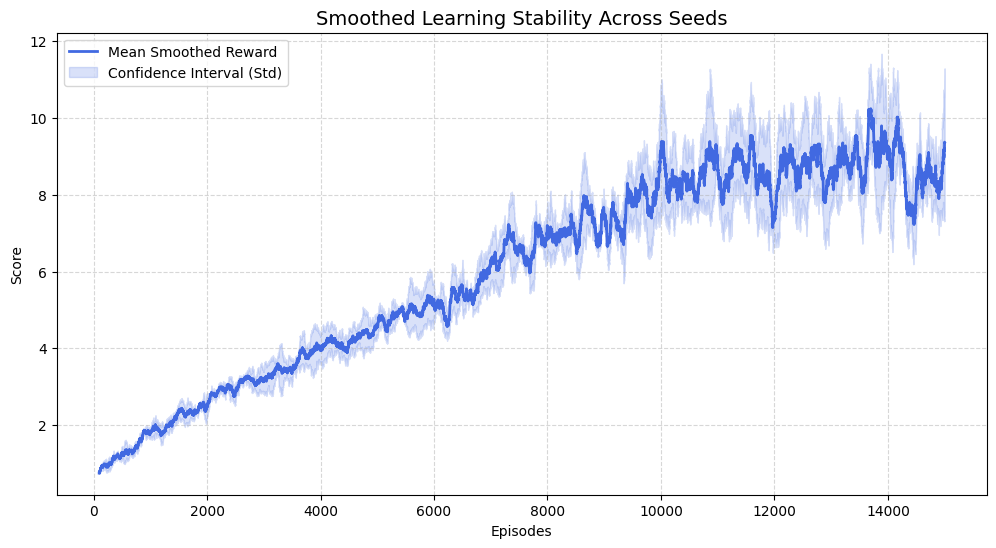

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

window = 100
rewards_array = np.array(list_reward_s)

# Apply moving average to each seed individually
smoothed_seeds = []
for i in range(len(list_reward_s)):
    smoothed = np.convolve(list_reward_s[i], np.ones(window)/window, mode='valid')
    smoothed_seeds.append(smoothed)

smoothed_seeds = np.array(smoothed_seeds)

# Calculate global mean and std across the smoothed seeds
mean_rewards = np.mean(smoothed_seeds, axis=0)
std_rewards = np.std(smoothed_seeds, axis=0)

plt.figure(figsize=(12, 6))
indices = range(window - 1, rewards_array.shape[1])

plt.plot(indices, mean_rewards, color='royalblue', linewidth=2, label='Mean Smoothed Reward')
plt.fill_between(indices, mean_rewards - std_rewards, mean_rewards + std_rewards, color='royalblue', alpha=.2, label='Confidence Interval (Std)')

plt.title("Smoothed Learning Stability Across Seeds", fontsize=14)
plt.xlabel("Episodes")
plt.ylabel("Score")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.show()

In [ ]:

Q_policy = find_Q_policy(list_Q_s[0])
Q_policy_rewards, Q_steps = evaluate_policy(env, Q_policy, num_episodes)
print(f"\n Q learning Policy:")
print(f"  Reward: {Q_policy_rewards.mean():.2f} +/- {Q_policy_rewards.std():.2f}")
print(f"  Steps:  {Q_steps.mean():.2f} +/- {Q_steps.std():.2f}")


 Q learning Policy:
  Reward: 10.46 +/- 8.33
  Steps:  120.60 +/- 95.98


In [ ]:
### Show the best algo
env_visual = gym.make("MinAtar/Breakout-v1", render_mode="rgb_array", disable_env_checker=True)
env_visual.reset()

frames, reward, steps = run_episode_with_frames(env_visual, Q_policy)
print(f"Episode: Reward = {reward}, Steps = {steps}")

anim = animate_episode(frames, interval=100)
HTML(anim.to_jshtml())


Episode: Reward = 43, Steps = 500


---

## Part 3: A Deep RL Method [10 marks]

Implement a reinforcement learning algorithm that uses neural networks for function approximation.

### Requirements

- Choose an appropriate algorithm
- Design a neural network architecture suited to the observation space
- Apply techniques to stabilize training as needed

### Questions to Address

1. **State representation**: Do you use the raw observation or a transformed representation? How does this choice influence your network architecture?

2. **Algorithm description**: What algorithm did you implement? Describe the loss function and update procedure.

3. **Architecture**: What neural network architecture did you use? Justify your design choices.

4. **Learning curves**: Plot training progress. Compare different hyperparameter choices, if applicable.

5. **Comparison**: How does the deep RL method compare to your classical RL method from Part 2? Consider sample efficiency, final performance, and training stability.

In [16]:
class DQN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=4, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(32*10*10, 128)
        self.fc2 = nn.Linear(128, 3)

    def forward(self, x):
        # x: batchx10x10x4
        x = F.relu(self.conv1(x))  # batchx10x10x16
        x = F.relu(self.conv2(x))  # batchx10x10x32
        x = F.relu(self.fc1(x.reshape(x.shape[0], 10*10*32)))  # batchx128
        x = self.fc2(x) # batchx4
        return x

In [17]:
def find_deep_Q_policy(Q, epsilon=None, with_exploration=False, device="cuda"):
    """Return the policy from the Q learning"""
    def policy(observation, num_actions):
        """The policy it returns"""
        if with_exploration:
            if np.random.uniform(0,1) < epsilon:
                return np.random.randint(num_actions)
        observation = np.transpose(observation, (2, 0, 1)).astype(np.float32)
        observation = torch.unsqueeze(torch.from_numpy(observation), 0).to(device)
        return torch.argmax(Q(observation))
    return policy

In [18]:
def warm_up_for_buffer(replay_buffer, nb_exp_warm_up):
  """Lunch a lot of rendom experience to start the buffer"""
  while len(replay_buffer) <= nb_exp_warm_up:
    observation, info = env.reset()
    num_actions = env.action_space.n
    terminated = False
    truncated = False

    while not (terminated or truncated):
        action = env.action_space.sample()
        old_observation = observation
        observation, reward, terminated, truncated, info = env.step(action)
        done = (terminated or truncated)
        replay_buffer.add(old_observation, action, reward, observation, float(done))


In [19]:
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def add(self, observation, action, reward, next_observation, done):
        self.buffer.append((observation, action, reward, next_observation, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        return batch

    def __len__(self):
        return len(self.buffer)

In [20]:
class HyperParamDeep:
  def __init__(self, alpha, gamma, epsilon_init, d, nb_epochs, display_every, punition_terminated, reward_truncated, memory_size, len_warm_up, batch_size, update_target_net, lr):
    self.alpha = alpha
    self.gamma = gamma
    self.epsilon_init = epsilon_init
    self.d = d
    self.nb_epochs = nb_epochs
    self.display_every = display_every
    self.punition_terminated = punition_terminated
    self.reward_truncated = reward_truncated
    self.memory_size = memory_size
    self.len_warm_up = len_warm_up
    self.batch_size = batch_size
    self.update_target_net = update_target_net
    self.lr = lr

In [21]:
hyper_param_d = HyperParamDeep(
    alpha=0.1,
    gamma=0.99,
    epsilon_init=1.0,
    d=0.9995,
    nb_epochs=15000,
    display_every=500,
    punition_terminated=-1,
    reward_truncated=0,
    memory_size=50000,
    len_warm_up=5000,
    batch_size=64,
    update_target_net=50,
    lr = 1e-4
)

In [22]:
def gradient_descent_Q(policy_net, target_net, replay_buffer, hyper_param_d, oprimizer, device):
  """Do the gradient descent on Q with the replay buffer"""

  batch = replay_buffer.sample(hyper_param_d.batch_size)
  observations, actions, rewards, next_observations, dones = zip(*batch)
  observation_t = torch.tensor(np.array(observations), dtype=torch.float32).to(device)
  action_t = torch.tensor(actions, dtype=torch.long).to(device)
  reward_t = torch.tensor(rewards, dtype=torch.float32).to(device)
  next_observation_t = torch.tensor(np.array(next_observations), dtype=torch.float32).to(device)
  dones_t = torch.tensor(dones, dtype=torch.float32).to(device)

  observation_t = observation_t.permute(0, 3, 1, 2)

  next_observation_t = next_observation_t.permute(0, 3, 1, 2)

  with torch.no_grad():
    max_values_target, _ = target_net(next_observation_t).max(dim=-1)
    target = reward_t + hyper_param_d.gamma * max_values_target * (1 - dones_t)

  current_q_values = policy_net(observation_t).gather(1, action_t.unsqueeze(1)).squeeze(1)
  loss = F.smooth_l1_loss(current_q_values, target)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()






In [23]:
def run_episode_deep_Q_learning_training(env, policy_net, target_net, epoch, hyper_param, find_deep_Q_policy, replay_buffer, optimizer, device):
    """Run one episode of Q learning"""

    observation, info = env.reset()
    num_actions = env.action_space.n

    total_reward = 0
    terminated = False
    truncated = False
    steps = 0


    while not (terminated or truncated):
        epsilon = hyper_param.epsilon_init * (hyper_param.d**epoch)
        policy = find_deep_Q_policy(policy_net, epsilon, with_exploration=True, device=device)
        action = policy(observation, num_actions)
        old_observation = observation
        observation, reward, terminated, truncated, info = env.step(action)
        if terminated:
          reward = hyper_param.punition_terminated
        if truncated:
          reward = hyper_param.reward_truncated
        done = terminated or truncated
        replay_buffer.add(old_observation, action, reward, observation, float(done))
        gradient_descent_Q(policy_net, target_net, replay_buffer, hyper_param_d, optimizer, device)
        total_reward += reward
        steps += 1
    return total_reward, steps

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on : {device}")

policy_net = DQN().to(device)
target_net = DQN().to(device)
optimizer = torch.optim.Adam(policy_net.parameters(), lr=hyper_param_d.lr)

target_net.load_state_dict(policy_net.state_dict())
target_net.eval()

replay_buffer = ReplayBuffer(hyper_param_d.memory_size)
print("Warm-up...")
warm_up_for_buffer(replay_buffer, hyper_param_d.len_warm_up)
print("Buffer ready")

rewards_history = []
moving_average_history = []
best_mean_reward = -float('inf')
window_size = 100

for epoch in range(hyper_param_d.nb_epochs):

    total_reward, steps = run_episode_deep_Q_learning_training(
        env, policy_net, target_net, epoch, hyper_param_d,
        find_deep_Q_policy, replay_buffer, optimizer, device
    )

    rewards_history.append(total_reward)


    current_mean = np.mean(rewards_history[-window_size:])
    moving_average_history.append(current_mean)

    if current_mean > best_mean_reward and epoch >= window_size:
        best_mean_reward = current_mean
        torch.save(policy_net.state_dict(), "best_model_breakout.pth")

    if epoch % hyper_param_d.update_target_net == 0:
        target_net.load_state_dict(policy_net.state_dict())

    if epoch % hyper_param_d.display_every == 0:
        current_eps = hyper_param_d.epsilon_init * (hyper_param_d.d**epoch)
        print(f"Episode {epoch:5d}/{hyper_param_d.nb_epochs} | "
              f"Score : {total_reward:5.1f} | "
              f"Mean (100) : {current_mean:5.1f} | "
              f"Best mean : {best_mean_reward:5.1f} | "
              f"Epsilon : {current_eps:.3f}")

print("End of training !")


Training on : cuda
Warm-up...
Buffer ready
Episode     0/15000 | Score :  -1.0 | Mean (100) :  -1.0 | Best mean :  -inf | Epsilon : 1.000
Episode   500/15000 | Score :  -1.0 | Mean (100) :  -0.3 | Best mean :  -0.2 | Epsilon : 0.779
Episode  1000/15000 | Score :   0.0 | Mean (100) :  -0.1 | Best mean :   0.1 | Epsilon : 0.606
Episode  1500/15000 | Score :   1.0 | Mean (100) :   0.6 | Best mean :   0.7 | Epsilon : 0.472
Episode  2000/15000 | Score :  -1.0 | Mean (100) :   0.5 | Best mean :   0.8 | Epsilon : 0.368


In [ ]:
## Use this code to restart a training that stoped with the last model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on : {device}")
checkpoint_path = "best_model_breakout.pth"
replay_buffer = ReplayBuffer(hyper_param_d.memory_size)
print("Warm-up...")
warm_up_for_buffer(replay_buffer, hyper_param_d.len_warm_up)
print("Buffer ready")
window_size = 100

policy_net = DQN().to(device)
target_net = DQN().to(device)


policy_net.load_state_dict(torch.load(checkpoint_path))
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()


optimizer = torch.optim.Adam(policy_net.parameters(), lr=hyper_param_d.lr)



rewards_history = []
moving_average_history = []
best_mean_reward = -float('inf')


start_epoch = 2000 

print(f"Restarting the training at epoch {start_epoch}...")

for epoch in range(start_epoch, hyper_param_d.nb_epochs):

    total_reward, steps = run_episode_deep_Q_learning_training(
        env, policy_net, target_net, epoch, hyper_param_d, 
        find_deep_Q_policy, replay_buffer, optimizer, device
    )

    rewards_history.append(total_reward)
    current_mean = np.mean(rewards_history[-window_size:])
    moving_average_history.append(current_mean)

    if current_mean > best_mean_reward and epoch >= window_size:
        best_mean_reward = current_mean
        torch.save(policy_net.state_dict(), "best_model_breakout.pth")

    if epoch % hyper_param_d.update_target_net == 0:
        target_net.load_state_dict(policy_net.state_dict())

    if epoch % hyper_param_d.display_every == 0:
        current_eps = max(0.05, hyper_param_d.epsilon_init * (hyper_param_d.d**epoch)) # Sécurité epsilon min
        print(f"Episode {epoch:5d}/{hyper_param_d.nb_epochs} | "
              f"Score : {total_reward:5.1f} | "
              f"Mean (100) : {current_mean:5.1f} | "
              f"Best mean : {best_mean_reward:5.1f} | "
              f"Epsilon : {current_eps:.3f}")


Training on : cuda
Warm-up...
Buffer ready
Restarting the training at epoch 2000...
Episode  2000/15000 | Score :  -1.0 | Mean (100) :  -1.0 | Best mean :  -1.0 | Epsilon : 0.368
Episode  2500/15000 | Score :  -1.0 | Mean (100) :   1.1 | Best mean :   1.2 | Epsilon : 0.286
Episode  3000/15000 | Score :   2.0 | Mean (100) :   1.9 | Best mean :   2.4 | Epsilon : 0.223
Episode  3500/15000 | Score :   0.0 | Mean (100) :   2.2 | Best mean :   3.3 | Epsilon : 0.174
Episode  4000/15000 | Score :   5.0 | Mean (100) :   3.7 | Best mean :   3.8 | Epsilon : 0.135
Episode  4500/15000 | Score :   7.0 | Mean (100) :   3.3 | Best mean :   4.3 | Epsilon : 0.105
Episode  5000/15000 | Score :  24.0 | Mean (100) :   6.9 | Best mean :   6.9 | Epsilon : 0.082
Episode  5500/15000 | Score :   8.0 | Mean (100) :   8.2 | Best mean :   8.7 | Epsilon : 0.064
Episode  6000/15000 | Score :  16.0 | Mean (100) :   8.2 | Best mean :   9.7 | Epsilon : 0.050
Episode  6500/15000 | Score :   3.0 | Mean (100) :  10.8 | Be

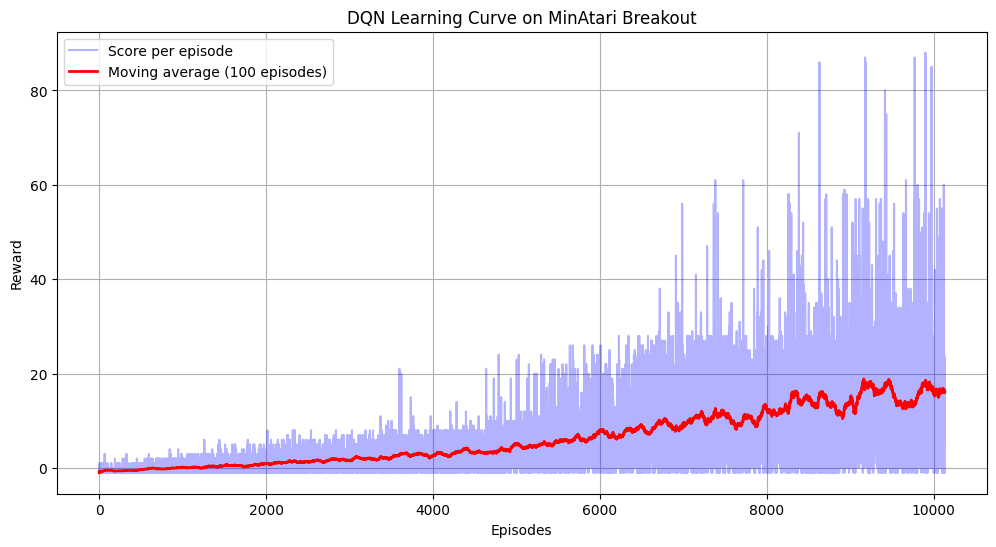

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(rewards_history, label='Score per episode', alpha=0.3, color='blue')
plt.plot(moving_average_history, label='Moving average (100 episodes)', color='red', linewidth=2)

plt.title("DQN Learning Curve on MinAtari Breakout")
plt.xlabel("Episodes")
plt.ylabel("Reward")
plt.legend()
plt.grid(True)
plt.show()

In [24]:
def find_final_deep_Q_policy():
    """Return the trained policy from the Q learning"""
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    trained_net = DQN().to(device)
    trained_net.load_state_dict(torch.load("best_model_breakout.pth", map_location=device))
    trained_net.eval()
    def policy(observation, num_actions):
        """The policy it returns"""
        observation = np.transpose(observation, (2, 0, 1)).astype(np.float32)
        observation = torch.unsqueeze(torch.from_numpy(observation), 0).to(device)
        return torch.argmax(trained_net(observation))
    return policy

In [25]:
deep_Q_policy = find_final_deep_Q_policy()
deep_Q_policy_rewards, deep_Q_steps = evaluate_policy(env, deep_Q_policy, num_episodes)
print(f"\n deep Q learning Policy:")
print(f"  Reward: {deep_Q_policy_rewards.mean():.2f} +/- {deep_Q_policy_rewards.std():.2f}")
print(f"  Steps:  {deep_Q_steps.mean():.2f} +/- {deep_Q_steps.std():.2f}")


 deep Q learning Policy:
  Reward: 23.64 +/- 24.49
  Steps:  287.06 +/- 341.19


In [26]:
### Show the best algo
env_visual = gym.make("MinAtar/Breakout-v1", render_mode="rgb_array", disable_env_checker=True)
env_visual.reset()

frames, reward, steps = run_episode_with_frames(env_visual, deep_Q_policy)
print(f"Episode: Reward = {reward}, Steps = {steps}")

anim = animate_episode(frames, interval=100)
HTML(anim.to_jshtml())

Episode: Reward = 31, Steps = 296


---

## Part 4: Policy Interpretation [8 marks]

Analyze the behavior of your trained agents.

### Questions to Address

1. **Qualitative behavior**: Report a video of your trained agent playing. Describe its strategy in words. Does it behave similarly to the heuristic, or has it learned a different approach?

2. **State-action analysis**: For your best policy, visualize what actions it selects in different states.

3. **Failure cases**: Identify situations where the policy makes poor decisions. What do these cases have in common?

4. **Comparison across methods**: Do your classical and deep RL methods learn similar or different strategies? If not, why ?

---

## Part 5: Improving Performance [4 marks]

Investigate techniques to improve your agents' performance and training stability.

### Requirements

Choose **at least two** of the following directions:

- **Ablation study**: Remove or modify components of your algorithm and measure the impact.
- **Variance reduction**: Implement and compare techniques to reduce gradient variance.
- **Regularization**: Experiment with regularization techniques and analyze their effects.
- **Hyperparameter sensitivity**: Systematically vary hyperparameters and report their effects.
- **Exploration strategies**: Compare different exploration methods. [At least 2]

### Instructions for the report

For each investigation:
- State your hypothesis before running experiments
- Present results with appropriate visualizations
- Discuss whether results matched your expectations and explain any surprises
- Discuss the limitations and their probable solutions of your proposed approach.

---

## Part 6: Generalization to Other Environments [5 marks]

Test whether your methods transfer to other MinAtar games: Asterix, Freeway, Seaquest, and Space Invaders.

### Questions to Address

1. **Direct transfer**: Apply your best Breakout agent (without retraining) to another game. Does it perform better than random? Why or why not?

2. **Retraining**: Train your deep RL method on at least one other MinAtar game. Does it achieve similar performance relative to the random baseline? If performance differs, explain why.

3. **Architecture/hyperparameter transfer**: Can you use the same configuration across games, or do different games require different configurations?

4. **Game difficulty**: Which games are easier or harder to learn? Relate this to environment properties.


---

## Summary

Conclude your notebook with a brief summary of:

- Your main findings across all parts
- What worked well and what did not
- What you would try next if you had more time

Make one paragraph answering these three points for each part of the assignment.